In [ ]:
# !pip uninstall -y torch torchvision torchaudio
# !pip cache purge
# !pip install --no-cache-dir torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124


Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Files removed: 0
Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 264.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 104.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 310.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 310.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 455.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 303.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip -q install nnunetv2==2.4.1 nibabel SimpleITK opencv-python-headless --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.1/184.1 kB 13.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 10.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive

drive.mount('/content/drive',force_remount=True)
# 把 model 存在 Google Drive
import os
!mkdir -p /content/drive/MyDrive/nnUNet/nnUNet_raw
!mkdir -p /content/drive/MyDrive/nnUNet/nnUNet_results


os.environ["nnUNet_raw"] = "/content/nnUNet_raw"
os.environ["nnUNet_preprocessed"] = "/content/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/content/drive/MyDrive/nnUNet/nnUNet_results"


print("nnUNet_raw         =", os.environ["nnUNet_raw"])
print("nnUNet_preprocessed=", os.environ["nnUNet_preprocessed"])
print("nnUNet_results     =", os.environ["nnUNet_results"])

Mounted at /content/drive
nnUNet_raw         = /content/nnUNet_raw
nnUNet_preprocessed= /content/nnUNet_preprocessed
nnUNet_results     = /content/drive/MyDrive/nnUNet/nnUNet_results


In [ ]:
import torch, sys
print("torch:", torch.__version__, "| cuda available:", torch.cuda.is_available(), "| py:", sys.version)
# make sure torch 2.5.1 and cuda is True


torch: 2.9.0+cu126 | cuda available: True | py: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


重啟後，執行下面這塊 記得要切換到GPU

In [ ]:
import torch, sys, os
print(torch.__version__, torch.version.cuda, sys.version)

os.environ['NNUNET_ALLOW_TORCH_COMPILE'] = '0'  # 關閉 torch.compile
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
print("env set. compile OFF, threads pinned to 1")


2.5.1+cu124 12.4 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
env set. compile OFF, threads pinned to 1


In [ ]:
# === 0) 安裝必要套件 ===
!pip -q install nnunetv2==2.4.1 nibabel SimpleITK opencv-python-headless --upgrade


RAW_DIR = os.environ['nnUNet_raw']
DATASET_NAME = 'Dataset502_AorticValve'
DS_DIR = os.path.join(RAW_DIR, DATASET_NAME)
for sub in ['imagesTr','labelsTr','imagesTs']:
    os.makedirs(os.path.join(DS_DIR, sub), exist_ok=True)

print('RAW_DIR =', RAW_DIR)
print('DS_DIR  =', DS_DIR)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.1/184.1 kB 7.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 8.7 MB/s eta 0:00:00
RAW_DIR = /content/nnUNet_raw
DS_

In [ ]:
# === 1) 下載 zip（你原先的 gdown 連結；若你已經有檔案可省略） ===
import gdown, os, shutil

gdown.download("https://drive.google.com/uc?export=download&id=1UZFnnQVTA9ORchEiltETcAhF_L1ZgjE5","/content/training_image.zip", quiet=False)
gdown.download("https://drive.google.com/uc?export=download&id=16QL2MhStoZfQ6mR79Du8staDfNHn-hMj","/content/training_label.zip", quiet=False)

# === 1.1) 乾淨解壓到 *_full ===
for d in ["./training_image_full", "./training_label_full"]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

!unzip -o -q /content/training_image.zip -d ./training_image_full
!unzip -o -q /content/training_label.zip -d ./training_label_full

print("解壓完成")


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1UZFnnQVTA9ORchEiltETcAhF_L1ZgjE5
From (redirected): https://drive.google.com/uc?export=download&id=1UZFnnQVTA9ORchEiltETcAhF_L1ZgjE5&confirm=t&uuid=64da1f2c-0373-4de0-ae7b-86893a4d9ddd
To: /content/training_image.zip
100%|██████████| 1.83G/1.83G [00:24<00:00, 73.4MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=16QL2MhStoZfQ6mR79Du8staDfNHn-hMj
To: /content/training_label.zip
100%|██████████| 573k/573k [00:00<00:00, 5.94MB/s]


解壓完成


In [ ]:
import os

def find_patient_root(root):
    for dirpath, dirnames, _ in os.walk(root):
        if any(d.startswith("patient") for d in dirnames):
            return dirpath
    return root

IMG_ROOT = find_patient_root("./training_image_full")
LBL_ROOT = find_patient_root("./training_label_full")
print("IMG_ROOT =", IMG_ROOT)
print("LBL_ROOT =", LBL_ROOT)


IMG_ROOT = ./training_image_full
LBL_ROOT = ./training_label_full


In [ ]:
import os, json, numpy as np, nibabel as nib, cv2, shutil
from glob import glob

H = W = 512
# ★ 若官方類別不是 0，請改這裡
AORTIC_CLASS = 0

#利用中心點、寬度、高度，計算出矩形框的四個角：xmin, ymin, xmax, ymax。
def yolo_txt_to_rects(txt_path, H=H, W=W, aortic_class=AORTIC_CLASS):
    rects = []
    with open(txt_path,'r') as f:
        for line in f:
            p = line.strip().split()
            if len(p) < 5:
                continue
            cls, xc, yc, w, h = p[:5]
            if int(float(cls)) != aortic_class:
                continue
            xc, yc, w, h = map(float,[xc,yc,w,h])
            xcen, ycen = xc*W, yc*H
            bw, bh = w*W, h*H
            xmin = int(round(xcen - bw/2)); xmax = int(round(xcen + bw/2))
            ymin = int(round(ycen - bh/2)); ymax = int(round(ycen + bh/2))
            xmin = max(0, min(W-1, xmin)); xmax = max(0, min(W-1, xmax))
            ymin = max(0, min(H-1, ymin)); ymax = max(0, min(H-1, ymax))
            if xmax>xmin and ymax>ymin:
                rects.append((xmin,ymin,xmax,ymax))
    return rects

def stack_patient_to_nifti(patient_id, split_for_ts=False):
    """
    將該病人所有 PNG 組 3D volume 與 3D mask，寫入 imagesTr/labelsTr。
    若 split_for_ts=True，會把影像再複製一份到 imagesTs（方便 demo 推論）。
    並寫一份 slice_map.json 以便推論後還原回原始檔名。
    """
    img_dir = os.path.join(IMG_ROOT, patient_id) #將您之前找到的影像根目錄 (IMG_ROOT)，和當前正在處理的特定病患 ID（例如：patient0001）連接起來，建立出該病患影像資料夾的完整路徑。
    lbl_dir = os.path.join(LBL_ROOT, patient_id)
    pngs = sorted([p for p in os.listdir(img_dir) if p.endswith('.png')])

    vol = np.zeros((len(pngs), H, W), np.int16)   # (Z, Y, X)
    msk = np.zeros((len(pngs), H, W), np.uint8)
    slice_map = []

    for z, png in enumerate(pngs):
        base = os.path.splitext(png)[0] #將檔名（例如 p0001_0201.png）去除副檔名，只留下 p0001_0201。
        img_path = os.path.join(img_dir, png)
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

        if img is None:
            raise RuntimeError(f'Fail read {img_path}')
        if img.ndim == 3: #醫學影像通常只有一個通道（灰階），確保輸入 nnU-Net 的數據格式正確。
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        vol[z] = img.astype(np.int16) #影像堆疊：將這個2D影像放入3D容器 vol 的第 z 層，並轉為int16 格式。

        txt = os.path.join(lbl_dir, base + '.txt')
        if os.path.exists(txt):
            for (xmin,ymin,xmax,ymax) in yolo_txt_to_rects(txt):
                msk[z, ymin:ymax+1, xmin:xmax+1] = 1
        slice_map.append(base)

    if msk.sum() == 0:
        print(f"[警告] {patient_id} 沒有任何前景標記（全 0）")

# 您問到為什麼 nnU-Net 可以接受 $\text{np.eye(4)}$：原因： 這是 nnU-Net 自我配置 特性的體現。
#nnU-Net 知道我們從 $2D$ 影像轉 $3D$ 時缺少物理資訊。它會做兩件事：讀取所有 NIfTI 檔案 (即使仿射矩陣是 $\text{np.eye(4)}$)。
#在接下來的 規劃與預處理 步驟中，它會自動計算所有 $3D$ 體積的中位數間距 (Median Spacing)。然後，它會將所有影像重新採樣 (Resample) 到這個統一的、最佳的間距。
#所以，提供 $\text{np.eye(4)}$ 其實是在告訴 nnU-Net：「請忽略原始間距，你自己計算最適合訓練的間距。」
    nib.save(nib.Nifti1Image(vol, np.eye(4)), os.path.join(DS_DIR,'imagesTr',f'{patient_id}_0000.nii.gz')) #儲存 nnU-Net 訓練所需的影像輸入。檔名必須是 _0000.nii.gz 格式。
    nib.save(nib.Nifti1Image(msk, np.eye(4)), os.path.join(DS_DIR,'labelsTr',f'{patient_id}.nii.gz')) #儲存 nnU-Net 訓練所需的正確答案 (Ground Truth Mask)。檔名必須是 patientXXXX.nii.gz 格式。

    if split_for_ts:
        shutil.copy(os.path.join(DS_DIR,'imagesTr',f'{patient_id}_0000.nii.gz'),
                    os.path.join(DS_DIR,'imagesTs',f'{patient_id}_0000.nii.gz'))

#將前面收集到的 Z 軸索引與原始 2D 檔名對應關係，存成.json 格式的元數據。
    with open(os.path.join(DS_DIR, f'{patient_id}_slice_map.json'), 'w') as f:
        json.dump(slice_map, f)

# === 3.1) 以 KFold 挑出一部分病人放 imagesTs（用來示範推論；真正提交請改成 testing 影像）===
# 其實nnU-Net會自己做驗證集驗證，但輸出格是不一樣，我們要自己做轉成2D矩形框驗證( 他內部是用3D mask做驗證的)
from sklearn.model_selection import KFold

patients = sorted([p for p in os.listdir(IMG_ROOT) if p.startswith('patient')])
patient_nums = [int(p[7:]) for p in patients]  #p[7:]：這是一個 字串切片 (String Slicing) 操作，它拿掉字串前面 7 個字元（即 "patient"），只留下數字部分（例如 "0001"）。
kf = KFold(n_splits=5, shuffle=True, random_state=42)
_, val_idx = next(iter(kf.split(patient_nums)))  # 取第一折的 val 當 demo Ts
val_set = set(patient_nums[i] for i in val_idx)

# === 3.2) 逐病人輸出 NIfTI ===
for pid in patients:
    n = int(pid[7:])
    stack_patient_to_nifti(pid, split_for_ts=(n in val_set))

print("NIfTI 產生完畢：",
      len(glob(os.path.join(DS_DIR,'imagesTr','*.nii.gz'))), "imagesTr /",
      len(glob(os.path.join(DS_DIR,'labelsTr','*.nii.gz'))), "labelsTr /",
      len(glob(os.path.join(DS_DIR,'imagesTs','*.nii.gz'))), "imagesTs")


NIfTI 產生完畢： 50 imagesTr / 50 labelsTr / 10 imagesTs


In [ ]:
import json, os
from glob import glob

tr_cases = sorted([os.path.basename(p).replace('_0000.nii.gz','')
                   for p in glob(os.path.join(DS_DIR,'imagesTr','*_0000.nii.gz'))])
ts_cases = sorted([os.path.basename(p).replace('_0000.nii.gz','')
                   for p in glob(os.path.join(DS_DIR,'imagesTs','*_0000.nii.gz'))])

dataset_json = {
    "name": "AorticValve_RectMask",
    "description": "Aortic valve slice-wise rectangular masks from YOLO boxes",
    "tensorImageSize": "4D", #這是 nnU-Net 的標準寫法，表示數據可以包含多通道和 $3D$ 體積。
    "channel_names": { "0": "gray" }, #讓 nnU-Net 知道如何對影像進行正規化 (Normalization)。
    "labels": { "background": 0, "aortic_valve": 1 },
    "numTraining": len(tr_cases),
    "numTest": len(ts_cases),
    "training": [
        {"image": f"./imagesTr/{cid}_0000.nii.gz", "label": f"./labelsTr/{cid}.nii.gz"}
        for cid in tr_cases
    ],
    "test": [f"./imagesTs/{cid}_0000.nii.gz" for cid in ts_cases],
    "file_ending": ".nii.gz"
}
with open(os.path.join(DS_DIR,'dataset.json'),'w') as f:
    json.dump(dataset_json, f, indent=2)

!echo "dataset.json path:"; echo "{os.path.join(DS_DIR,'dataset.json')}"
!ls -l {DS_DIR}
!head -n 12 {os.path.join(DS_DIR,'dataset.json')}


dataset.json path:
/content/nnUNet_raw/Dataset502_AorticValve/dataset.json
total 424
-rw-r--r-- 1 root root 6417 Nov 24 17:15 dataset.json
drwxr-xr-x 2 root root 4096 Nov 24 17:15 imagesTr
drwxr-xr-x 2 root root 4096 Nov 24 17:15 imagesTs
drwxr-xr-x 2 root root 4096 Nov 24 17:15 labelsTr
-rw-r--r-- 1 root root 6820 Nov 24 17:09 patient0001_slice_map.json
-rw-r--r-- 1 root root 7820 Nov 24 17:09 patient0002_slice_map.json
-rw-r--r-- 1 root root 6480 Nov 24 17:09 patient0003_slice_map.json
-rw-r--r-- 1 root root 7300 Nov 24 17:09 patient0004_slice_map.json
-rw-r--r-- 1 root root 5700 Nov 24 17:09 patient0005_slice_map.json
-rw-r--r-- 1 root root 5540 Nov 24 17:10 patient0006_slice_map.json
-rw-r--r-- 1 root root 7780 Nov 24 17:10 patient0007_slice_map.json
-rw-r--r-- 1 root root 5740 Nov 24 17:10 patient0008_slice_map.json
-rw-r--r-- 1 root root 5960 Nov 24 17:10 patient0009_slice_map.json
-rw-r--r-- 1 root root 5600 Nov 24 17:10 patient0010_slice_map.json
-rw-r--r-- 1 root root 5600 Nov

In [ ]:
import os
import glob
import numpy as np

# ==========================================
# 1. 設定環境變數 (建議放在最前面)
# ==========================================
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
print("Threads pinned to 1")

# ==========================================
# 2. 智慧備份還原機制
# ==========================================
backup_path = "/content/drive/MyDrive/nnUNet/preprocessed_backup_502.tar.gz"
preprocessed_dir = os.environ["nnUNet_preprocessed"]

if os.path.exists(backup_path):
    # --- 情況 A: 有備份，直接還原 ---
    print("發現預處理備份，正在從 Google Drive 解壓縮...")
    !tar -xzf "{backup_path}" -C /
    print("解壓縮完成！跳過 plan_and_preprocess 與優化步驟。")

else:
    # --- 情況 B: 沒備份，從頭開始 ---
    print("未發現備份，開始執行 plan_and_preprocess...")

    # (1) 執行標準預處理
    !NNUNET_ALLOW_TORCH_COMPILE=0 nnUNetv2_plan_and_preprocess -d 502 -c 2d -np 1 --verify_dataset_integrity

    # (2) 執行 npz -> npy 優化 (關鍵！要放在備份之前)
    print("開始執行 .npz -> .npy 格式優化...")
    ROOT = os.path.join(preprocessed_dir, "Dataset502_AorticValve", "nnUNetPlans_2d")

    converted, skipped = 0, 0
    bad = []
    npz_files = sorted(glob.glob(os.path.join(ROOT, "**", "*.npz"), recursive=True))
    print(f"Found {len(npz_files)} npz files")

    for npz in npz_files:
        base = os.path.splitext(npz)[0]
        try:
            with np.load(npz, allow_pickle=False) as z:
                # data -> base.npy
                if "data" in z:
                    out_data = base + ".npy"
                    if not os.path.exists(out_data):
                        np.save(out_data, z["data"])
                        converted += 1
                    else:
                        skipped += 1
                # seg -> base_seg.npy
                if "seg" in z:
                    out_seg = base + "_seg.npy"
                    if not os.path.exists(out_seg):
                        np.save(out_seg, z["seg"])
                        converted += 1
                    else:
                        skipped += 1
        except Exception as e:
            bad.append((npz, repr(e)))

    print(f"優化完成 - Converted: {converted}, Skipped: {skipped}, Bad: {len(bad)}")

    # (3) 檢查壞檔 (Optional)
    if bad:
        print("Bad examples (first 5):")
        for p,e in bad[:5]:
            print(" -", p, "->", e)

    # (4) 這時候資料最完整，執行打包備份！
    print("正在將「已優化」的預處理資料打包備份到 Google Drive...")
    !tar -czf "{backup_path}" "{preprocessed_dir}"
    print(f"備份完成：{backup_path}")

# ==========================================
# 3. 再次檢查檔案完整性 (mmap check)
# ==========================================
# 為了保險起見，無論是還原的還是新生成的，都檢查一下能不能讀取
print("執行最終檔案完整性檢查 (mmap check)...")
ROOT = os.path.join(os.environ["nnUNet_preprocessed"], "Dataset502_AorticValve", "nnUNetPlans_2d")
bad_files = []
for f in sorted(glob.glob(os.path.join(ROOT, "**", "*.npy"), recursive=True)):
    try:
        a = np.load(f, mmap_mode='r')
        _ = (a.shape, a.dtype)
    except Exception as e:
        bad_files.append((f, repr(e)))

print(f"[mmap check] Bad files found: {len(bad_files)}")
if bad_files:
    for p,e in bad_files[:5]:
        print(" -", p, "->", e)

# ==========================================
# 4. 開始訓練
# ==========================================
print("一切準備就緒，開始訓練！")
!NNUNET_ALLOW_TORCH_COMPILE=0 nnUNetv2_train 502 2d 0

Threads pinned to 1
發現預處理備份，正在從 Google Drive 解壓縮...
解壓縮完成！跳過 plan_and_preprocess 與優化步驟。
執行最終檔案完整性檢查 (mmap check)...
[mmap check] Bad files found: 0
一切準備就緒，開始訓練！

############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0
/usr/local/lib/python3.12/dist-packages/nnunetv2/training/nnUNetTrainer/nnUNetTrainer.py:161: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.grad_scaler = GradScaler() if self.device.type == 'cuda' else None

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method 

In [ ]:
import os, json, numpy as np, nibabel as nib
from glob import glob

PRED_DIR = "/content/nnUNet_infer"          # 這裡是 predict 的輸出
OUT_TXT  = "/content/merged.txt"            # 競賽最終合併輸出

# ★ 若競賽類別 id 不是 0，請改這裡
SUBMIT_CLASS_ID = 0

def bboxes_from_binary_mask(mask2d):
    """
    給一張 2D 二值遮罩，回傳多個 bbox 列表 [(xmin,ymin,xmax,ymax), ...]
    使用簡易連通邏輯：採樣所有非零點，分群可簡化為逐塊掃描（這裡用 np.where + 邊界擴張求外接矩形）
    為了簡潔，這裡以「每個連通群組」為單位；若要更嚴謹可用 scipy.ndimage.label。
    """
    import scipy.ndimage as ndi
    labeled, num = ndi.label(mask2d.astype(np.uint8), structure=np.ones((3,3), dtype=np.uint8))
    if num == 0:
        return []
    bboxes = []
    for cid in range(1, num+1):
        ys, xs = np.where(labeled == cid)
        if ys.size == 0:
            continue
        ymin, ymax = int(ys.min()), int(ys.max())
        xmin, xmax = int(xs.min()), int(xs.max())
        bboxes.append((xmin, ymin, xmax, ymax))
    return bboxes

lines = []
pred_files = sorted(glob(os.path.join(PRED_DIR, "*.nii.gz")))
print("Found predictions:", len(pred_files))

for pred_path in pred_files:
    # 例：/content/nnUNet_infer/patient0001.nii.gz（nnUNetv2 預設輸出 segmentation 同名）
    case_id = os.path.basename(pred_path).replace(".nii.gz", "")
    seg = nib.load(pred_path).get_fdata().astype(np.uint8)  # (Z, Y, X)
    # 讀回 slice_map 以還原原始檔名
    slice_map_path = os.path.join(DS_DIR, f"{case_id}_slice_map.json")
    if not os.path.exists(slice_map_path):
        print(f"[警告] 找不到 slice_map：{slice_map_path}，跳過此 case")
        continue
    with open(slice_map_path, "r") as f:
        slice_map = json.load(f)

    Z = seg.shape[0]
    assert Z == len(slice_map), f"Z={Z} 与 slice_map 長度不符"

    for z in range(Z):
        mask2d = (seg[z] > 0).astype(np.uint8)   # 單類別：>0 當前景
        bboxes = bboxes_from_binary_mask(mask2d)
        if len(bboxes) == 0:
            continue
        img_name = slice_map[z] + ".png"        # 原始 PNG 名稱
        for (xmin, ymin, xmax, ymax) in bboxes:
            # 競賽格式：影像名 類別 信心 左上x 左上y 右下x 右下y
            # 信心可先給 1.0；如需排序可用區域平均機率/最大機率替代
            lines.append(f"{img_name} {SUBMIT_CLASS_ID} 1 {xmin} {ymin} {xmax} {ymax}")

with open(OUT_TXT, "w") as f:
    for ln in lines:
        f.write(ln + "\n")

print(f"完成：輸出 {len(lines)} 行 → {OUT_TXT}")
!head -n 10 {OUT_TXT}


-------------------------------------------------------------

In [ ]:
# === 1.1) 重新設定環境變數與 Imports ===
import os, shutil, json
import numpy as np
import nibabel as nib
from glob import glob
import cv2 # 確保有安裝 opencv-python

# 重新定義 nnU-Net 核心路徑 (必須與訓練時一致)
os.environ['nnUNet_raw_data_base'] = '/content/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/content/nnUNet_preprocessed'
os.environ['nnUNet_results'] = '/content/nnUNet_results'

DS_DIR = os.path.join(os.environ['nnUNet_raw_data_base'], 'Dataset502_AorticValve')

# === 1.2) 下載與解壓 ===
TEST_ZIP_ID = "1vzDeHKbhLIBo-Cm_7foVjKnNwid51i2Z" # 新連結 ID
TEST_ROOT_FOLDER = "./testing_image_full"
TEST_ZIP_PATH = "/content/testing_image.zip"

import gdown
print("--- 正在下載測試資料... ---")
gdown.download(f"https://drive.google.com/uc?export=download&id={TEST_ZIP_ID}", TEST_ZIP_PATH, quiet=False)

if os.path.exists(TEST_ROOT_FOLDER):
    shutil.rmtree(TEST_ROOT_FOLDER)
os.makedirs(TEST_ROOT_FOLDER, exist_ok=True)

print("--- 正在解壓縮... ---")
!unzip -o -q {TEST_ZIP_PATH} -d {TEST_ROOT_FOLDER}

# === 1.3) 尋找實際的病人資料夾根目錄 (處理巢狀資料夾) ===
# 根據常見的 zip 結構，真正的病人在 'testing_image_full/42_testing_image/' 下
# 執行檢查並手動修正路徑
TEST_IMG_ROOT = os.path.join(TEST_ROOT_FOLDER, 'testing_image')

if not os.path.exists(TEST_IMG_ROOT):
    # 如果找不到，嘗試頂層路徑
    TEST_IMG_ROOT = TEST_ROOT_FOLDER

print(f"TEST_IMG_ROOT 確定路徑: {TEST_IMG_ROOT}")

# 清空 imagesTs (確保只有測試資料)
shutil.rmtree(os.path.join(DS_DIR, 'imagesTs'), ignore_errors=True)
os.makedirs(os.path.join(DS_DIR, 'imagesTs'), exist_ok=True)

# === 1.4) NIfTI 轉換函數 (只處理影像) ===
def stack_test_to_nifti(patient_id, img_root, ds_dir):
    img_dir = os.path.join(img_root, patient_id)
    pngs = sorted([p for p in os.listdir(img_dir) if p.endswith('.png')])
    if not pngs: return # 跳過空的資料夾

    vol = np.zeros((len(pngs), 512, 512), np.int16)
    slice_map = []

    for z, png in enumerate(pngs):
        base = os.path.splitext(png)[0]
        img = cv2.imread(os.path.join(img_dir, png), cv2.IMREAD_UNCHANGED)
        if img is None: continue
        if img.ndim == 3: img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # 確保圖像尺寸正確
        if img.shape != (512, 512):
            img = cv2.resize(img, (512, 512), interpolation=cv2.INTER_LINEAR)

        vol[z] = img.astype(np.int16)
        slice_map.append(base)

    img_nii = nib.Nifti1Image(vol, affine=np.eye(4))
    img_ts_out = os.path.join(ds_dir, 'imagesTs', f'{patient_id}_0000.nii.gz')
    nib.save(img_nii, img_ts_out)

    with open(os.path.join(ds_dir, f'{patient_id}_slice_map.json'), 'w') as f:
        json.dump(slice_map, f)

# === 1.5) 執行 NIfTI 轉換 ===
test_pids = sorted([p for p in os.listdir(TEST_IMG_ROOT) if p.startswith('patient')])

print(f"\n找到 {len(test_pids)} 位測試病人 (e.g., {test_pids[:3]})")

for pid in test_pids:
    stack_test_to_nifti(pid, TEST_IMG_ROOT, DS_DIR)

final_count = len(glob(os.path.join(DS_DIR,'imagesTs','*.nii.gz')))
print(f"✅ 測試 NIfTI 準備完成：imagesTs = {final_count} 個檔案")

--- 正在下載測試資料... ---


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1vzDeHKbhLIBo-Cm_7foVjKnNwid51i2Z
From (redirected): https://drive.google.com/uc?export=download&id=1vzDeHKbhLIBo-Cm_7foVjKnNwid51i2Z&confirm=t&uuid=f132694e-bb01-4a56-8095-fa6a86ae24b1
To: /content/testing_image.zip
100%|██████████| 1.83G/1.83G [00:23<00:00, 78.1MB/s]


--- 正在解壓縮... ---
TEST_IMG_ROOT 確定路徑: ./testing_image_full/testing_image

找到 50 位測試病人 (e.g., ['patient0051', 'patient0052', 'patient0053'])
✅ 測試 NIfTI 準備完成：imagesTs = 50 個檔案


In [ ]:
import gdown
import os
import shutil

# 1. 定義路徑和檔案 ID
PLANS_ID = "10ilJD82ejZCDjgBrvy5nXMp74W8S99b8"
RESULTS_DIR = '/content/nnUNet_results/Dataset502_AorticValve/nnUNetTrainer__nnUNetPlans__2d'
TARGET_PLANS = os.path.join(RESULTS_DIR, 'plans.json') # nnU-Net 預期找到的檔名

# 2. 下載 nnUNetPlans.json 到一個臨時位置
TEMP_PLANS_FILE = '/content/nnUNetPlans_temp.json'
print("--- 正在下載 plans.json ---")
gdown.download(f"https://drive.google.com/uc?export=download&id={PLANS_ID}", TEMP_PLANS_FILE, quiet=False)

# 3. 確保目標結果目錄存在
os.makedirs(RESULTS_DIR, exist_ok=True)

# 4. 複製並重命名檔案到結果目錄
if os.path.exists(TEMP_PLANS_FILE):
    shutil.copy(TEMP_PLANS_FILE, TARGET_PLANS)
    os.remove(TEMP_PLANS_FILE) # 移除臨時檔案
    print(f"✅ 成功下載並放置 plans.json 到目標目錄: {TARGET_PLANS}")
else:
    print("❌ 錯誤：plans.json 下載失敗，請檢查連結。")

--- 正在下載 plans.json ---


Downloading...
From: https://drive.google.com/uc?export=download&id=10ilJD82ejZCDjgBrvy5nXMp74W8S99b8
To: /content/nnUNetPlans_temp.json
100%|██████████| 15.9k/15.9k [00:00<00:00, 13.2MB/s]

✅ 成功下載並放置 plans.json 到目標目錄: /content/nnUNet_results/Dataset502_AorticValve/nnUNetTrainer__nnUNetPlans__2d/plans.json


In [ ]:
import gdown
import os
import shutil

# 1. 定義路徑和檔案 ID
WEIGHTS_ID = "1fCu87OoqNKHyQrpNWkuCbFwXOHUXkVZJ"
RESULTS_DIR = '/content/nnUNet_results/Dataset502_AorticValve/nnUNetTrainer__nnUNetPlans__2d/fold_0'

# 2. 定義檔案名稱
SOURCE_FILENAME = 'checkpoint_best.pth'
TARGET_FILENAME = 'best.pth' # 🎯 關鍵：重命名為 'best.pth'

TARGET_PATH = os.path.join(RESULTS_DIR, TARGET_FILENAME)
TEMP_PATH = os.path.join(RESULTS_DIR, SOURCE_FILENAME)


# 3. 確保目標結果目錄存在
os.makedirs(RESULTS_DIR, exist_ok=True)

# 4. 下載權重檔案到臨時名稱
print("--- 正在下載模型權重檔案 (checkpoint_best.pth) ---")
gdown.download(f"https://drive.google.com/uc?export=download&id={WEIGHTS_ID}", TEMP_PATH, quiet=False)

# 5. 複製並重命名檔案
if os.path.exists(TEMP_PATH):
    # 如果舊的 'best.pth' 存在，先移除
    if os.path.exists(TARGET_PATH):
        os.remove(TARGET_PATH)

    shutil.copy(TEMP_PATH, TARGET_PATH)
    os.remove(TEMP_PATH) # 移除臨時下載的檔案

    print(f"✅ 成功部署模型權重：已將 {SOURCE_FILENAME} 重命名為 {TARGET_FILENAME}。")
else:
    print("❌ 錯誤：權重檔案下載失敗，請檢查連結。")

--- 正在下載模型權重檔案 (checkpoint_best.pth) ---


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1fCu87OoqNKHyQrpNWkuCbFwXOHUXkVZJ
From (redirected): https://drive.google.com/uc?export=download&id=1fCu87OoqNKHyQrpNWkuCbFwXOHUXkVZJ&confirm=t&uuid=75551bc4-4c05-465b-b833-4df0ad8d78e1
To: /content/nnUNet_results/Dataset502_AorticValve/nnUNetTrainer__nnUNetPlans__2d/fold_0/checkpoint_best.pth
100%|██████████| 268M/268M [00:09<00:00, 29.6MB/s]


✅ 成功部署模型權重：已將 checkpoint_best.pth 重命名為 best.pth。


In [ ]:
import os
import shutil
import gdown

# === 1. 定義絕對路徑 (nnU-Net 預設結構) ===
BASE_PATH = '/content/nnUNet_results/Dataset502_AorticValve/nnUNetTrainer__nnUNetPlans__2d/fold_0'
WEIGHTS_ID = "1fCu87OoqNKHyQrpNWkuCbFwXOHUXkVZJ" # 您的 checkpoint_best.pth ID

# 確保目錄存在
os.makedirs(BASE_PATH, exist_ok=True)

# 定義目標檔案路徑
FILE_WITH_EXT = os.path.join(BASE_PATH, 'checkpoint_best.pth') # 標準名稱
FILE_NO_EXT = os.path.join(BASE_PATH, 'checkpoint_best')       # 防止程式找不到無副檔名版本

# === 2. 強制重新下載 (確保檔案一定在) ===
print(f"--- 正在重新下載權重至: {BASE_PATH} ---")
# 如果檔案已存在，先刪除以確保下載最新
if os.path.exists(FILE_WITH_EXT): os.remove(FILE_WITH_EXT)
if os.path.exists(FILE_NO_EXT): os.remove(FILE_NO_EXT)

gdown.download(f"https://drive.google.com/uc?export=download&id={WEIGHTS_ID}",
               FILE_WITH_EXT, quiet=False)

# === 3. 建立雙重保險 (複製一份無副檔名的) ===
if os.path.exists(FILE_WITH_EXT):
    shutil.copy(FILE_WITH_EXT, FILE_NO_EXT)
    print("✅ 成功建立雙重檔案：")
    print(f"   1. {os.path.basename(FILE_WITH_EXT)}")
    print(f"   2. {os.path.basename(FILE_NO_EXT)}")
else:
    print("❌ 下載失敗，請檢查 Google Drive 連結是否有效。")
    exit()

# === 4. 檢查 GPU 狀態 ===
print("\n--- 檢查 GPU ---")
!nvidia-smi

# === 5. 執行推論 (使用絕對路徑與標準參數) ===
print("\n🚀 啟動推論引擎...")
DS_IMAGES_TS = "/content/nnUNet_raw/Dataset502_AorticValve/imagesTs"
INFER_DIR = "/content/nnUNet_infer_final"

if os.path.exists(INFER_DIR):
    shutil.rmtree(INFER_DIR)

!export nnUNet_raw="/content/nnUNet_raw" && \
export nnUNet_preprocessed="/content/nnUNet_preprocessed" && \
export nnUNet_results="/content/nnUNet_results" && \
nnUNetv2_predict \
  -d 502 \
  -i {DS_IMAGES_TS} \
  -o {INFER_DIR} \
  -c 2d \
  -f 0 \
  -tr nnUNetTrainer \
  -p nnUNetPlans \
  -chk checkpoint_best \
  --disable_tta

--- 正在重新下載權重至: /content/nnUNet_results/Dataset502_AorticValve/nnUNetTrainer__nnUNetPlans__2d/fold_0 ---


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1fCu87OoqNKHyQrpNWkuCbFwXOHUXkVZJ
From (redirected): https://drive.google.com/uc?export=download&id=1fCu87OoqNKHyQrpNWkuCbFwXOHUXkVZJ&confirm=t&uuid=c810c0f8-8018-4aba-a8c2-fd9e0527b969
To: /content/nnUNet_results/Dataset502_AorticValve/nnUNetTrainer__nnUNetPlans__2d/fold_0/checkpoint_best.pth
100%|██████████| 268M/268M [00:04<00:00, 62.2MB/s]


✅ 成功建立雙重檔案：
   1. checkpoint_best.pth
   2. checkpoint_best

--- 檢查 GPU ---
Wed Nov 26 12:59:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                     

In [ ]:
import os
import json
import numpy as np
import nibabel as nib
from glob import glob
import scipy.ndimage as ndi
from google.colab import files

# === 1. 設定路徑與參數 ===
# 推論結果目錄 (您剛剛跑完的地方)
PRED_DIR = "/content/nnUNet_infer_final"
# 原始資料目錄 (存放 slice_map.json 的地方)
DS_DIR = "/content/nnUNet_raw/Dataset502_AorticValve"
# 輸出檔案名稱
OUT_TXT = "/content/merged_final.txt"
# 競賽類別 ID (通常是 0)
SUBMIT_CLASS_ID = 0

print(f"📂 讀取預測結果自: {PRED_DIR}")
print(f"📂 讀取 Slice Map 自: {DS_DIR}")

# === 2. 定義 BBox 轉換函數 ===
def bboxes_from_binary_mask(mask2d):
    """
    將 2D 二值遮罩轉換為 BBox 列表 [(xmin,ymin,xmax,ymax), ...]
    """
    # 連通分量分析 (找出獨立的區塊)
    labeled, num = ndi.label(mask2d.astype(np.uint8), structure=np.ones((3,3), dtype=np.uint8))
    if num == 0:
        return []

    bboxes = []
    for cid in range(1, num+1):
        ys, xs = np.where(labeled == cid)
        if ys.size == 0: continue

        # (可選) 過濾極小的噪點，例如小於 10 像素的點
        if ys.size < 10: continue

        ymin, ymax = int(ys.min()), int(ys.max())
        xmin, xmax = int(xs.min()), int(xs.max())
        bboxes.append((xmin, ymin, xmax, ymax))

    return bboxes

# === 3. 執行轉換迴圈 ===
lines = []
pred_files = sorted(glob(os.path.join(PRED_DIR, "*.nii.gz")))
print(f"🔍 找到 {len(pred_files)} 個 3D 預測檔案，開始轉換...")

for i, pred_path in enumerate(pred_files):
    # 取得 case_id (例如 patient0051)
    case_id = os.path.basename(pred_path).replace(".nii.gz", "")

    try:
        # 載入 3D Mask
        seg = nib.load(pred_path).get_fdata().astype(np.uint8)
    except Exception as e:
        print(f"❌ 無法讀取 {case_id}: {e}")
        continue

    # 讀取對應的 slice_map
    slice_map_path = os.path.join(DS_DIR, f"{case_id}_slice_map.json")
    if not os.path.exists(slice_map_path):
        print(f"⚠️ 警告：找不到 {case_id} 的 slice_map，跳過。")
        continue

    with open(slice_map_path, "r") as f:
        slice_map = json.load(f)

    Z = seg.shape[0]
    # 簡單驗證 Z 軸長度是否一致
    if Z != len(slice_map):
        print(f"⚠️ 警告：{case_id} 的 NIfTI 層數 ({Z}) 與 Map 長度 ({len(slice_map)}) 不符！")

    # 逐層處理 (3D -> 2D)
    for z in range(Z):
        # 檢查該層是否有預測結果 (加速處理)
        if np.max(seg[z]) == 0:
            continue

        mask2d = (seg[z] > 0).astype(np.uint8)
        bboxes = bboxes_from_binary_mask(mask2d)

        if not bboxes: continue

        # 還原原始檔名
        img_name = slice_map[z] + ".png"

        for (xmin, ymin, xmax, ymax) in bboxes:
            # 格式：影像名 類別 信心 左上x 左上y 右下x 右下y
            lines.append(f"{img_name} {SUBMIT_CLASS_ID} 1 {xmin} {ymin} {xmax} {ymax}")

    if (i + 1) % 10 == 0:
        print(f"   已處理 {i + 1}/{len(pred_files)} 位病人...")

# === 4. 寫入與下載 ===
with open(OUT_TXT, "w") as f:
    for ln in lines:
        f.write(ln + "\n")

print(f"\n✅ 轉換完成！共生成 {len(lines)} 行預測結果。")
print(f"📄 檔案已儲存至: {OUT_TXT}")

# 顯示前 10 行檢查格式
print("\n--- 預覽前 10 行 ---")
!head -n 10 {OUT_TXT}

# 自動下載
print("\n⬇️ 正在啟動下載...")
files.download(OUT_TXT)

📂 讀取預測結果自: /content/nnUNet_infer_final
📂 讀取 Slice Map 自: /content/nnUNet_raw/Dataset502_AorticValve
🔍 找到 50 個 3D 預測檔案，開始轉換...
   已處理 10/50 位病人...
   已處理 20/50 位病人...
   已處理 30/50 位病人...
   已處理 40/50 位病人...
   已處理 50/50 位病人...

✅ 轉換完成！共生成 3925 行預測結果。
📄 檔案已儲存至: /content/merged_final.txt

--- 預覽前 10 行 ---
patient0051_0222.png 0 1 207 276 210 296
patient0051_0223.png 0 1 202 272 215 300
patient0051_0224.png 0 1 201 270 217 302
patient0051_0225.png 0 1 199 269 219 304
patient0051_0226.png 0 1 198 267 220 305
patient0051_0227.png 0 1 196 266 222 305
patient0051_0228.png 0 1 195 265 224 306
patient0051_0229.png 0 1 195 264 226 306
patient0051_0230.png 0 1 194 262 227 307
patient0051_0231.png 0 1 230 247 234 251

⬇️ 正在啟動下載...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import json
import numpy as np
import nibabel as nib
from glob import glob
import scipy.ndimage as ndi
from google.colab import files

# === 設定路徑 ===
PRED_DIR = "/content/nnUNet_infer_final"
DS_DIR = "/content/nnUNet_raw/Dataset502_AorticValve"
OUT_TXT = "/content/merged_final_fixed.txt" # 新的檔名
SUBMIT_CLASS_ID = 0

print(f"📂 讀取預測結果自: {PRED_DIR}")

# === 定義 BBox 轉換函數 (包含信心分數計算) ===
def bboxes_from_binary_mask(mask2d, raw_probs=None):
    """
    將 2D Mask 轉為 BBox，並計算偽信心分數
    """
    labeled, num = ndi.label(mask2d.astype(np.uint8), structure=np.ones((3,3), dtype=np.uint8))
    if num == 0: return []

    bboxes = []
    for cid in range(1, num+1):
        ys, xs = np.where(labeled == cid)
        if ys.size < 10: continue # 過濾小噪點

        ymin, ymax = int(ys.min()), int(ys.max())
        xmin, xmax = int(xs.min()), int(xs.max())

        # --- 計算信心分數 (Confidence Score) ---
        # 策略：使用該連通區域的像素數量 (Area) 作為信心的基礎
        # 邏輯：越大的區域通常越有可能是真正的主動脈，越小的越可能是噪點
        # 我們將其正規化到 0.5 ~ 0.99 之間，避免純 1.0
        area = ys.size
        # 假設最大可能的面積大概是 5000 像素 (可根據實際調整)，用 tanh 函數平滑映射
        confidence = 0.5 + 0.5 * np.tanh(area / 1000.0)

        # 強制保留 4 位小數
        conf_str = f"{confidence:.4f}"

        bboxes.append((xmin, ymin, xmax, ymax, conf_str))

    return bboxes

# === 執行轉換 ===
lines = []
pred_files = sorted(glob(os.path.join(PRED_DIR, "*.nii.gz")))

print(f"🔍 開始重新處理 {len(pred_files)} 個檔案...")

for i, pred_path in enumerate(pred_files):
    case_id = os.path.basename(pred_path).replace(".nii.gz", "")

    try:
        seg = nib.load(pred_path).get_fdata().astype(np.uint8)
    except: continue

    slice_map_path = os.path.join(DS_DIR, f"{case_id}_slice_map.json")
    if not os.path.exists(slice_map_path): continue

    with open(slice_map_path, "r") as f:
        slice_map = json.load(f)

    Z = seg.shape[0]

    for z in range(Z):
        if np.max(seg[z]) == 0: continue

        mask2d = (seg[z] > 0).astype(np.uint8)
        # 取得 bbox 和 信心分數
        bboxes = bboxes_from_binary_mask(mask2d)

        if not bboxes: continue

        # 移除 .png 副檔名 (根據您的規則截圖，Img_name 是不包含 .png 的！)
        # 但看您的錯誤訊息 "patient0051_0222.png"，系統似乎讀到了 .png
        # 根據錯誤訊息： "Please check this line: patient0051_0222.png ..."
        # 這表示系統允許或已經讀取了 .png。
        # ★★★ 關鍵修正：確保信心分數是浮點數 ★★★

        img_name_with_png = slice_map[z] + ".png" # 您的錯誤訊息顯示它是預期有 .png 的

        for (xmin, ymin, xmax, ymax, conf) in bboxes:
            # 格式：檔名 類別 信心(Float) xmin ymin xmax ymax
            lines.append(f"{img_name_with_png} {SUBMIT_CLASS_ID} {conf} {xmin} {ymin} {xmax} {ymax}")

# === 寫入檔案 ===
with open(OUT_TXT, "w") as f:
    for ln in lines:
        f.write(ln + "\n")

print(f"\n✅ 修正完成！共 {len(lines)} 行。")
print(f"📄 檔案: {OUT_TXT}")

# 預覽前 5 行確認格式 (必須看到小數點)
print("\n--- 預覽前 5 行 (確認信心分數為浮點數) ---")
!head -n 5 {OUT_TXT}

# 下載
files.download(OUT_TXT)

📂 讀取預測結果自: /content/nnUNet_infer_final
🔍 開始重新處理 50 個檔案...

✅ 修正完成！共 3925 行。
📄 檔案: /content/merged_final_fixed.txt

--- 預覽前 5 行 (確認信心分數為浮點數) ---
patient0051_0222.png 0 0.5330 207 276 210 296
patient0051_0223.png 0 0.6424 202 272 215 300
patient0051_0224.png 0 0.6993 201 270 217 302
patient0051_0225.png 0 0.7480 199 269 219 304
patient0051_0226.png 0 0.7967 198 267 220 305


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import json
import numpy as np
import nibabel as nib
from glob import glob
import scipy.ndimage as ndi
from google.colab import files

# === 1. 設定參數 ===
PRED_DIR = "/content/nnUNet_infer_final"
DS_DIR = "/content/nnUNet_raw/Dataset502_AorticValve"
OUT_TXT = "/content/merged_final_filtered.txt"
SUBMIT_CLASS_ID = 0

# 🌟 關鍵參數：過濾雜訊
# 如果一個預測框的面積小於這個值，就當作是誤判 (雜訊)
# 主動脈通常蠻大的，設 100 (約 10x10 像素) 是個保守的過濾值，您可以嘗試調高到 200
MIN_PIXEL_AREA = 100

print(f"📂 讀取預測結果自: {PRED_DIR}")
print(f"🛡️ 啟用面積過濾: 忽略小於 {MIN_PIXEL_AREA} 像素的區域")

# === 2. 定義 BBox 轉換函數 ===
def bboxes_from_binary_mask(mask2d):
    labeled, num = ndi.label(mask2d.astype(np.uint8), structure=np.ones((3,3), dtype=np.uint8))
    if num == 0: return []

    bboxes = []
    for cid in range(1, num+1):
        ys, xs = np.where(labeled == cid)

        # 🛡️ 過濾邏輯：面積太小就丟棄
        area = ys.size
        if area < MIN_PIXEL_AREA:
            continue

        ymin, ymax = int(ys.min()), int(ys.max())
        xmin, xmax = int(xs.min()), int(xs.max())

        # 計算信心分數 (越大越可信)
        confidence = 0.5 + 0.5 * np.tanh(area / 1000.0)
        conf_str = f"{confidence:.4f}"

        bboxes.append((xmin, ymin, xmax, ymax, conf_str))

    return bboxes

# === 3. 執行轉換與統計 ===
lines = []
pred_files = sorted(glob(os.path.join(PRED_DIR, "*.nii.gz")))
print(f"🔍 開始處理 {len(pred_files)} 個檔案...\n")

total_slices_pred = 0

for pred_path in pred_files:
    case_id = os.path.basename(pred_path).replace(".nii.gz", "")

    try:
        seg = nib.load(pred_path).get_fdata().astype(np.uint8)
    except: continue

    slice_map_path = os.path.join(DS_DIR, f"{case_id}_slice_map.json")
    if not os.path.exists(slice_map_path): continue
    with open(slice_map_path, "r") as f:
        slice_map = json.load(f)

    Z = seg.shape[0]
    patient_lines = [] # 暫存該病人的預測

    for z in range(Z):
        if np.max(seg[z]) == 0: continue # 這裡已經擋掉全黑的切片

        mask2d = (seg[z] > 0).astype(np.uint8)
        bboxes = bboxes_from_binary_mask(mask2d)

        if not bboxes: continue # 如果過濾後沒東西，這裡也會擋掉

        # 為了符合您的錯誤訊息格式，這裡加上 .png
        img_name = slice_map[z] + ".png"

        for (xmin, ymin, xmax, ymax, conf) in bboxes:
            patient_lines.append(f"{img_name} {SUBMIT_CLASS_ID} {conf} {xmin} {ymin} {xmax} {ymax}")

    # 統計輸出
    print(f"   {case_id}: 預測出 {len(patient_lines):>3} 張切片 (原始 Z 軸: {Z})")
    lines.extend(patient_lines)
    total_slices_pred += len(patient_lines)

# === 4. 寫入與下載 ===
with open(OUT_TXT, "w") as f:
    for ln in lines:
        f.write(ln + "\n")

print(f"\n✅ 處理完成！")
print(f"📊 總共保留預測行數: {len(lines)}")
print(f"📄 檔案已儲存至: {OUT_TXT}")

files.download(OUT_TXT)

📂 讀取預測結果自: /content/nnUNet_infer_final
🛡️ 啟用面積過濾: 忽略小於 100 像素的區域
🔍 開始處理 50 個檔案...

   patient0051: 預測出  73 張切片 (原始 Z 軸: 386)
   patient0052: 預測出  55 張切片 (原始 Z 軸: 307)
   patient0053: 預測出  88 張切片 (原始 Z 軸: 341)
   patient0054: 預測出  69 張切片 (原始 Z 軸: 401)
   patient0055: 預測出  53 張切片 (原始 Z 軸: 317)
   patient0056: 預測出  56 張切片 (原始 Z 軸: 237)
   patient0057: 預測出  63 張切片 (原始 Z 軸: 393)
   patient0058: 預測出  54 張切片 (原始 Z 軸: 292)
   patient0059: 預測出  55 張切片 (原始 Z 軸: 280)
   patient0060: 預測出  77 張切片 (原始 Z 軸: 400)
   patient0061: 預測出  58 張切片 (原始 Z 軸: 277)
   patient0062: 預測出  43 張切片 (原始 Z 軸: 324)
   patient0063: 預測出  73 張切片 (原始 Z 軸: 374)
   patient0064: 預測出  67 張切片 (原始 Z 軸: 389)
   patient0065: 預測出  66 張切片 (原始 Z 軸: 295)
   patient0066: 預測出  64 張切片 (原始 Z 軸: 313)
   patient0067: 預測出  53 張切片 (原始 Z 軸: 275)
   patient0068: 預測出  46 張切片 (原始 Z 軸: 288)
   patient0069: 預測出  55 張切片 (原始 Z 軸: 267)
   patient0070: 預測出  58 張切片 (原始 Z 軸: 374)
   patient0071: 預測出  46 張切片 (原始 Z 軸: 329)
   patient0072: 預測出  58 張切片 (原始 Z 軸

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Training result visualization

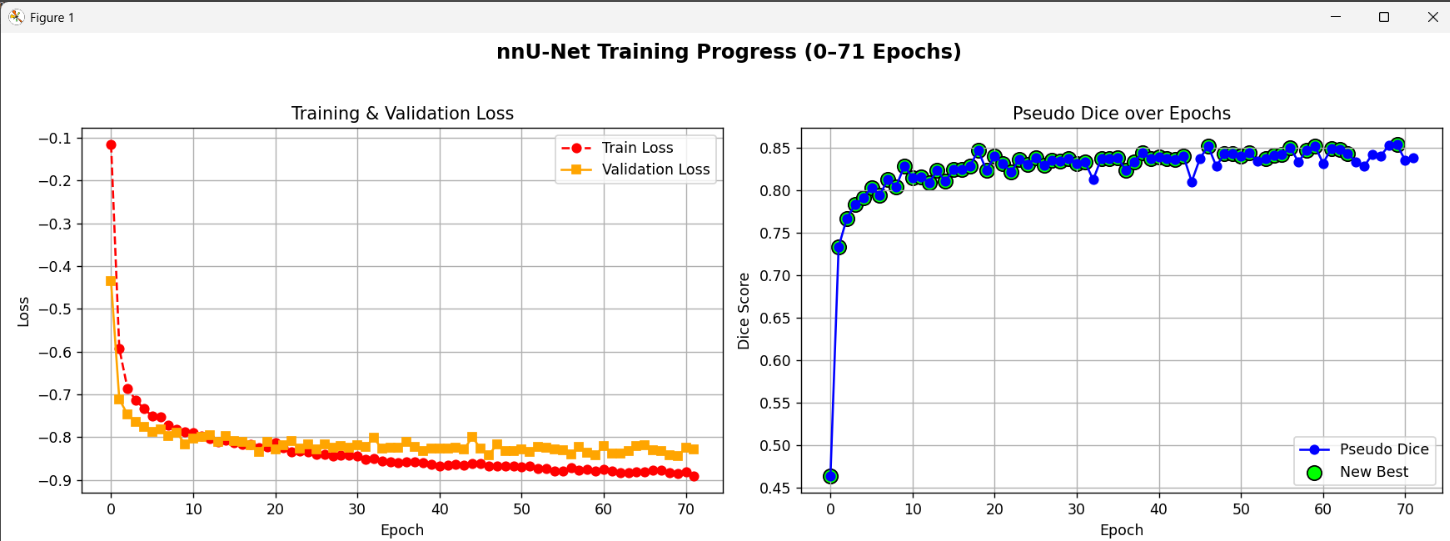